# Distributed ET comparison — gridded OpenET + easymore vs OpenET polygon-reduce

Compares two ways of getting **per-HRU** observed evapotranspiration over the
elevation×aspect HRUs for the **East** and **Tuolumne** rivers:

1. **gridded + easymore** — native OpenET raster (`/raster/geotiff/stack`, ensemble,
   monthly) downloaded over the basin, coarsened to ~240 m, then area-weight
   remapped onto the HRU polygons with EASYMORE.
   Producer: `ess-project/modeling/calibration/download_gridded_et.py`
   + `remap_et_to_hrus.py`.
2. **polygon-reduce** — one OpenET polygon API call per HRU (Earth Engine does the
   spatial mean). Producer: `download_distributed_et.py --per-hru`.

The gridded approach downloads the basin **once** and can be remapped to any HRU
discretization; the polygon-reduce approach re-queries per HRU per discretization.
This notebook checks the two agree and visualizes the per-HRU ET fields.


In [1]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np, pandas as pd, xarray as xr, geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import xarray as xr

DATA_ROOT = Path("/scratch/dlhogan/ess-project-data")

BASINS = {
    "East": {
        "domain_dir": DATA_ROOT / "domain_East_River_distributed_elevAspect",
        "shp": "shapefiles/catchment/East_River_distributed_elevAspect_HRUs_elevation_aspect.shp",
        "gridded_csv": "observations/et/openet_et_gridded_East_elevAspect_monthly.csv",
        "polyreduce_basin": "observations/et/openet_et_ensemble_East_elevAspect_monthly.csv",
        "polyreduce_hru": "observations/et/openet_et_per_hru_distributed_elevAspect_monthly.csv",
    },
    "Tuolumne": {
        "domain_dir": DATA_ROOT / "domain_Tuolumne_River_distributed_elevAspect",
        "shp": "shapefiles/catchment/Tuolumne_River_distributed_elevAspect_HRUs_elevation_aspect.shp",
        "gridded_csv": "observations/et/openet_et_gridded_Tuolumne_elevAspect_monthly.csv",
        "polyreduce_basin": "observations/et/openet_et_ensemble_Tuolumne_elevAspect_monthly.csv",
        "polyreduce_hru": "observations/et/openet_et_per_hru_distributed_elevAspect_monthly.csv",
    },
}
HRU_ID = "HRU_ID"


## Loaders

In [2]:
def load_gridded_hru(cfg):
    """Per-HRU gridded+easymore ET as a wide DataFrame (date index, hru_<id> cols)."""
    df = pd.read_csv(cfg["domain_dir"] / cfg["gridded_csv"], parse_dates=["date"]).set_index("date")
    df.columns = [c.replace("hru_", "") for c in df.columns]  # keep bare HRU ids
    return df.sort_index()

def hru_area_weights(cfg):
    g = gpd.read_file(cfg["domain_dir"] / cfg["shp"]).to_crs(5070)
    a = g.set_index(g[HRU_ID].astype(str))["geometry"].area
    return (a / a.sum())

def basin_mean(hru_df, weights):
    cols = [c for c in hru_df.columns if c in weights.index]
    w = weights.loc[cols].values
    w = w / w.sum()
    return (hru_df[cols].values * w[None, :]).sum(axis=1)

def load_polyreduce_basin(cfg):
    p = cfg["domain_dir"] / cfg["polyreduce_basin"]
    if not p.exists():
        return None
    return pd.read_csv(p, parse_dates=["date"]).set_index("date")["et"].sort_index()


## Load both basins

In [38]:
loaded = {}
for name, cfg in BASINS.items():
    gpath = cfg["domain_dir"] / cfg["gridded_csv"]
    if not gpath.exists():
        print(f"[skip] {name}: gridded CSV not found yet ({gpath.name}) — run download+remap first")
        continue
    hru_df = load_gridded_hru(cfg)
    w = hru_area_weights(cfg)
    loaded[name] = {
        "hru": hru_df,
        "weights": w,
        "basin_grid": pd.Series(basin_mean(hru_df, w), index=hru_df.index),
        "basin_poly": load_polyreduce_basin(cfg),
    }
    print(f"{name}: {hru_df.shape[0]} months x {hru_df.shape[1]} HRUs, "
          f"{hru_df.index.min():%Y-%m} .. {hru_df.index.max():%Y-%m}")


East: 108 months x 18 HRUs, 2016-10 .. 2025-09
Tuolumne: 108 months x 28 HRUs, 2016-10 .. 2025-09


## Load model results

In [39]:
# East River
ER_RESULT_PATH = "/scratch/dlhogan/ess-project-data/calibration/bestruns/East_River_baseline_1981_2025/run/out/baseline_timestep.nc"
er_baseline_results = -xr.open_dataset(ER_RESULT_PATH)[['scalarTotalET', 'scalarSnowSublimation']].squeeze().sel(time=slice("2016-10-01", "2025-09-30")).resample(time="1M").sum()*3600
# add scalarTotalET and scalarSnowSublimation to get total ET
total_ET = er_baseline_results['scalarTotalET'] + er_baseline_results['scalarSnowSublimation']
total_ET.name = 'totalET'
er_ET_results = total_ET.to_dataframe().reset_index().pivot(index='time', columns='hru', values='totalET')

In [40]:
# East RivTR
TR_RESULT_PATH = "/scratch/dlhogan/ess-project-data/calibration/bestruns/Tuolumne_River_baseline_wbias10_1981_2025/run/out/baseline_timestep.nc"
TR_baseline_results = -xr.open_dataset(TR_RESULT_PATH)[['scalarTotalET', 'scalarSnowSublimation']].squeeze().sel(time=slice("2016-10-01", "2025-09-30")).resample(time="1M").sum()*3600
# add scalarTotalET and scalarSnowSublimation to get total ET
total_ET = TR_baseline_results['scalarTotalET'] + TR_baseline_results['scalarSnowSublimation']
total_ET.name = 'totalET'
TR_ET_results = total_ET.to_dataframe().reset_index().pivot(index='time', columns='hru', values='totalET')

## Figure 1 — basin-mean ET: gridded+easymore vs polygon-reduce

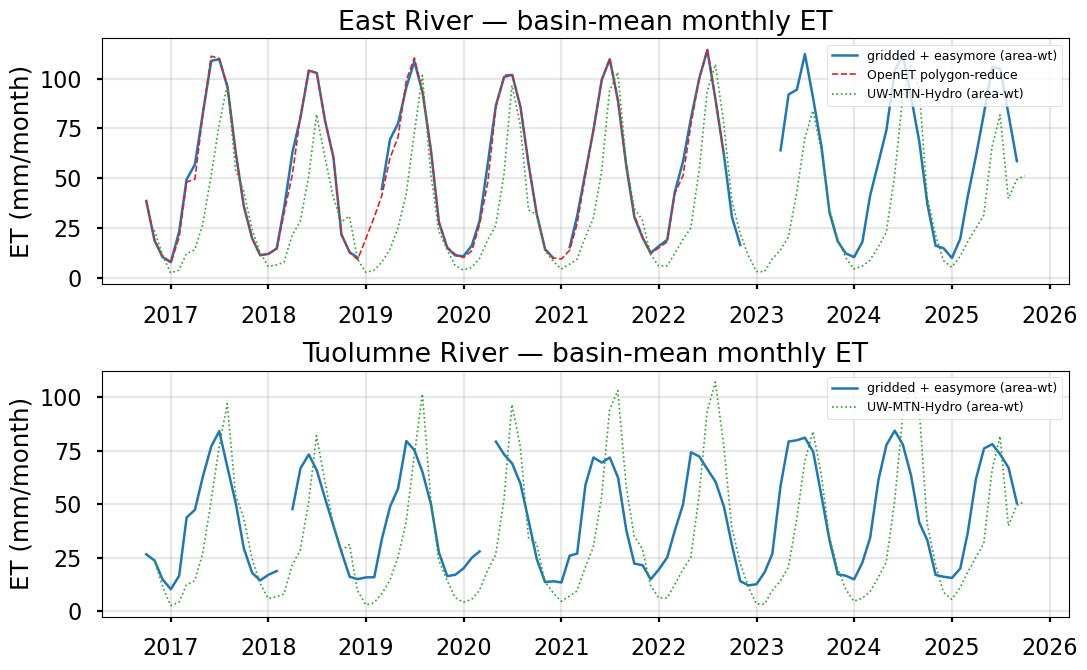

In [41]:
fig, axes = plt.subplots(len(loaded), 1, figsize=(11, 3.4*len(loaded)), squeeze=False)
for ax, (name, d) in zip(axes[:, 0], loaded.items()):
    ax.plot(d["basin_grid"].index, d["basin_grid"].values, lw=1.8,
            label="gridded + easymore (area-wt)", color="#1f77b4")
    if d["basin_poly"] is not None:
        bp = d["basin_poly"].reindex(d["basin_grid"].index)
        ax.plot(bp.index, bp.values, lw=1.2, ls="--",
                label="OpenET polygon-reduce", color="#d62728")
    ax.plot(er_ET_results.index, er_ET_results.mean(axis=1), lw=1.2, ls=":",
            label="UW-MTN-Hydro (area-wt)", color="#2ca02c")
    ax.set_title(f"{name} River — basin-mean monthly ET")
    ax.set_ylabel("ET (mm/month)"); ax.legend(loc="upper right", fontsize=9)
    ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


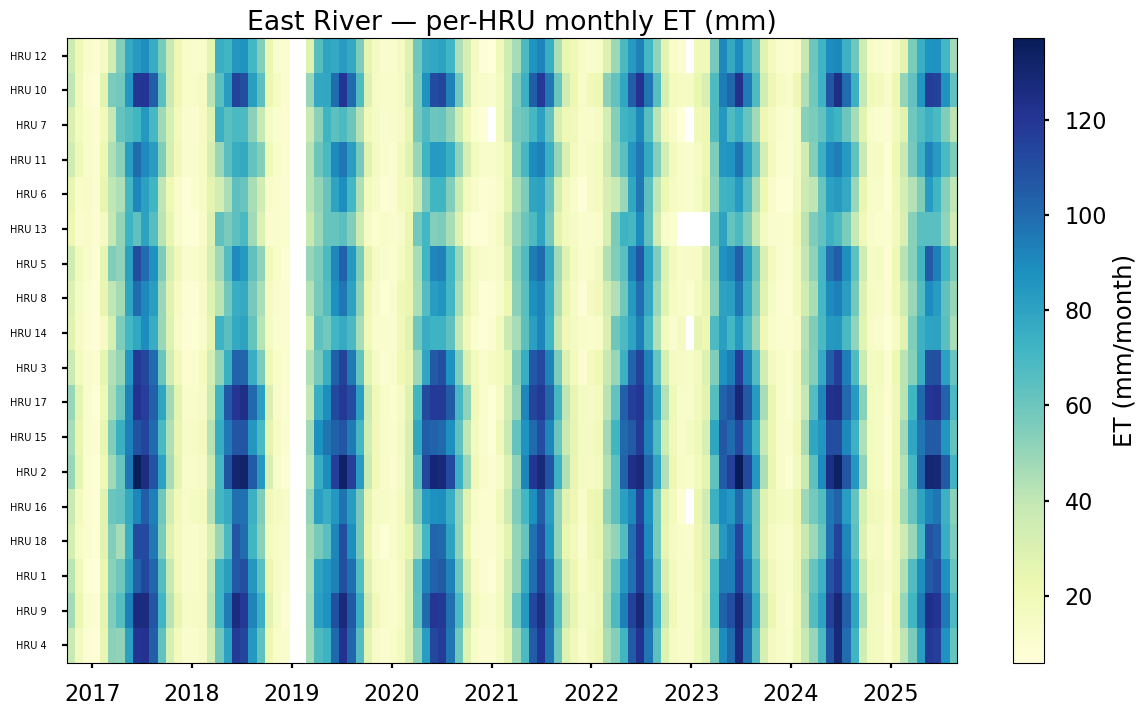

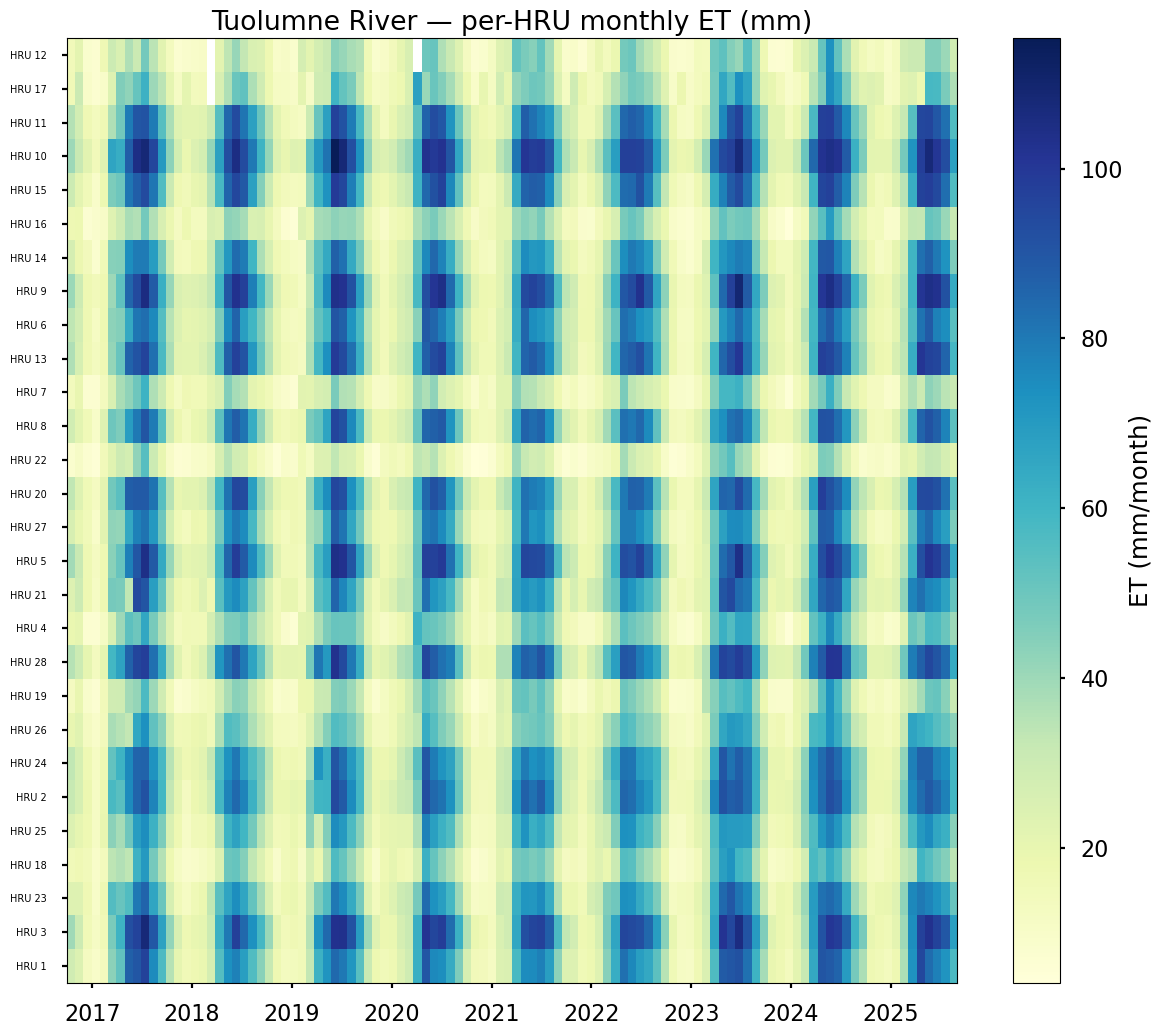

In [42]:

for name, d in loaded.items():
    hru_df = d["hru"]
    order = d["weights"].reindex(hru_df.columns).sort_values().index  # small->large HRU
    M = hru_df[order].T.values
    fig, ax = plt.subplots(figsize=(12, 0.32*len(order)+1.5))
    im = ax.imshow(M, aspect="auto", cmap="YlGnBu",
                   extent=[mdates.date2num(hru_df.index[0]), mdates.date2num(hru_df.index[-1]),
                           0, len(order)])
    ax.xaxis_date(); ax.set_yticks(np.arange(len(order))+0.5)
    ax.set_yticklabels([f"HRU {h}" for h in order], fontsize=7)
    ax.set_title(f"{name} River — per-HRU monthly ET (mm)")
    fig.colorbar(im, ax=ax, label="ET (mm/month)")
    plt.tight_layout(); plt.show()


## Figure 4 — mean-annual ET per HRU (map)

East River — mean annual ET from OpenET: 535.3 mm/yr
East River — mean annual ET from modified results: 373.6 mm/yr
Tuolumne River — mean annual ET from OpenET: 456.9 mm/yr
Tuolumne River — mean annual ET from modified results: 373.6 mm/yr


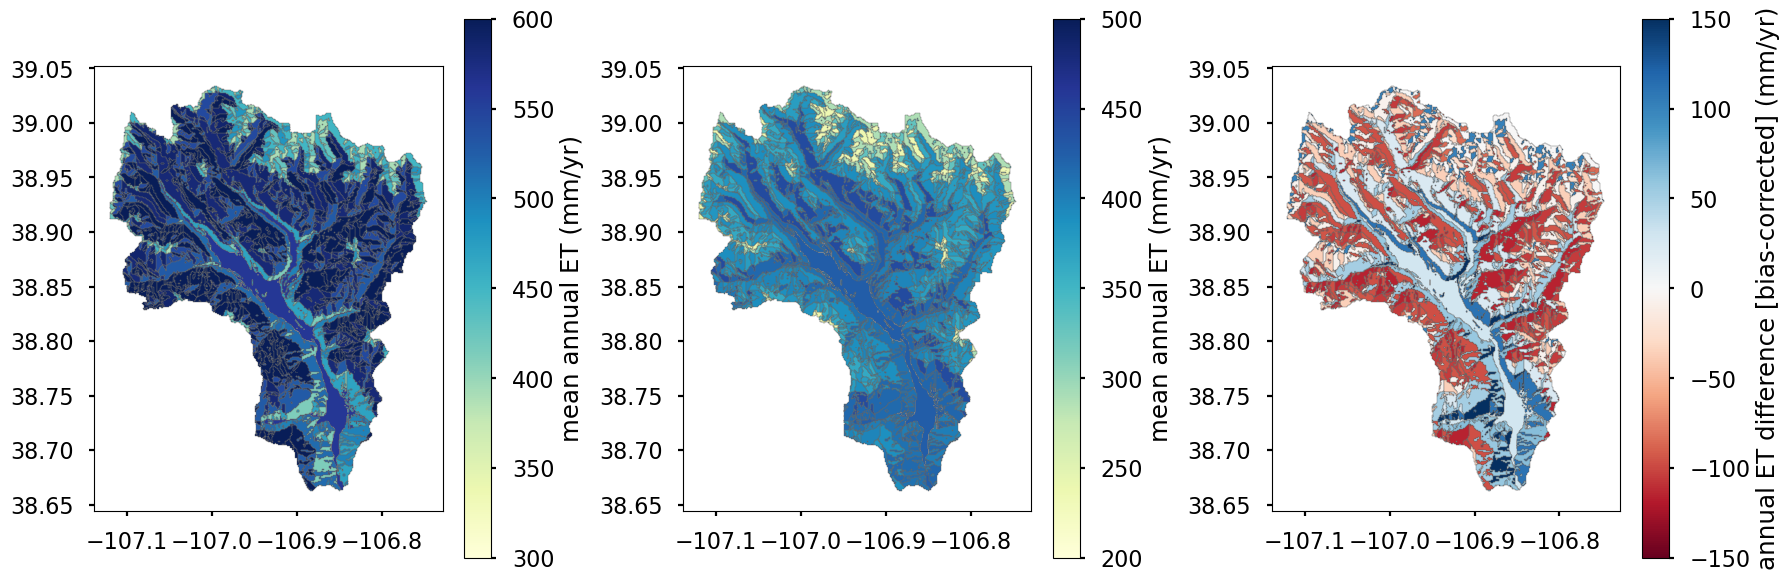

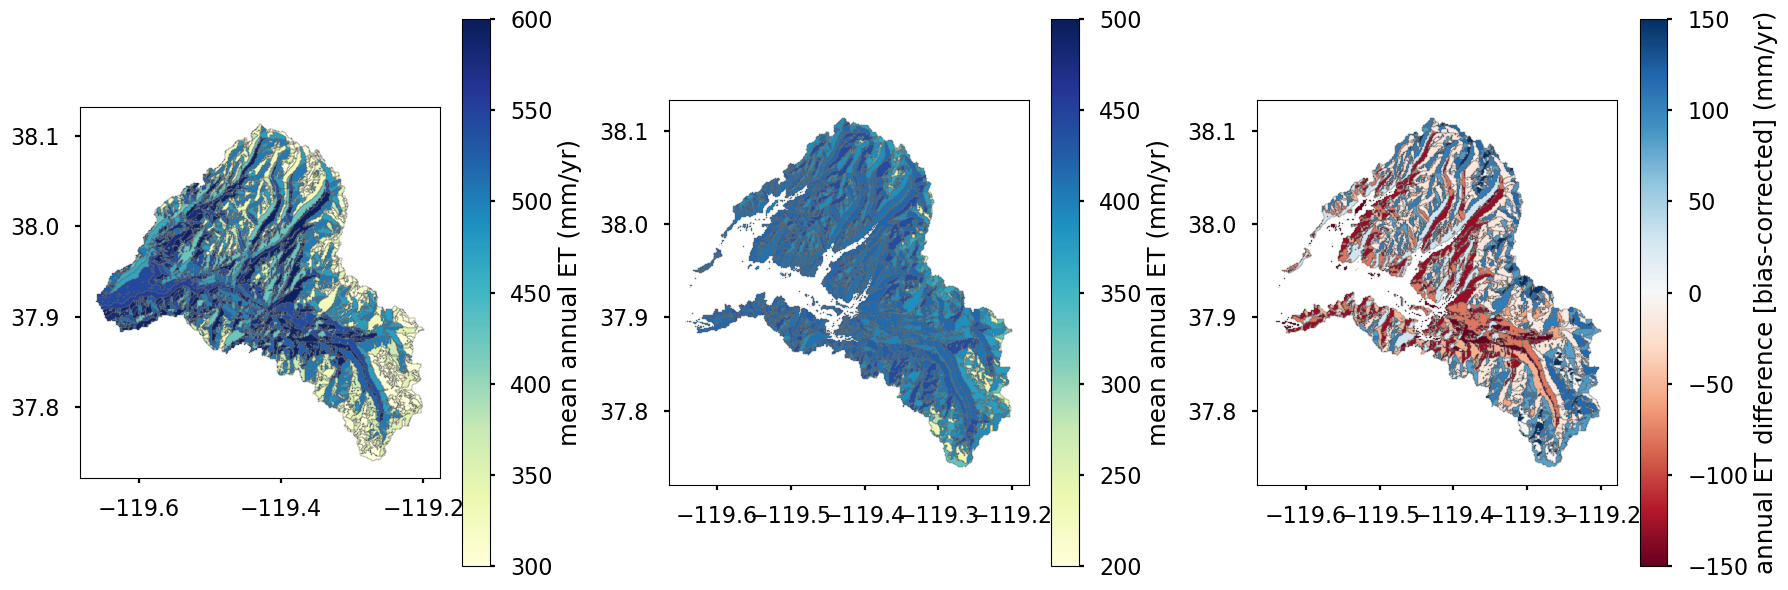

In [43]:
for name, d in loaded.items():
    cfg = BASINS[name]
    g = gpd.read_file(cfg["domain_dir"] / cfg["shp"]).to_crs(4326)
    g["id_str"] = g[HRU_ID].astype(str)
    ann = d["hru"].resample("YS").sum().mean(axis=0)  # mean annual ET per HRU (mm/yr)
    g["et_ann"] = g["id_str"].map(ann.to_dict())
    fig, axs = plt.subplots(ncols=3, figsize=(18, 6))
    ax = axs[0]
    g.plot(column="et_ann", cmap="YlGnBu", legend=True, edgecolor="0.4", lw=0.3, ax=axs[0],
           legend_kwds={"label": "mean annual ET (mm/yr)"}, vmin=300, vmax=600)

    ax = axs[1]
    ann_mod = er_ET_results.resample("YS").sum().mean(axis=0)  # mean annual ET per HRU (mm/yr)
    # drop index name
    ann_mod.index.name = None
    # convert index to string to match HRU_ID type in shapefile
    ann_mod.index = ann_mod.index.astype(str)
    g["et_ann_mod"] = g["id_str"].map(ann_mod.to_dict())
    g.plot(column="et_ann_mod", cmap="YlGnBu", legend=True, edgecolor="0.4", lw=0.3, ax=axs[1],
           legend_kwds={"label": "mean annual ET (mm/yr)"}, vmin=200, vmax=500)

    ax = axs[2]
    g['openet_mod_diff'] = (g['et_ann_mod'] - g['et_ann']) - (np.mean(g['et_ann_mod'] - g['et_ann']))
    g.plot(column="openet_mod_diff", cmap="RdBu", legend=True, edgecolor="0.4", lw=0.3, ax=axs[2],
                 legend_kwds={"label": "annual ET difference [bias-corrected] (mm/yr)"}, vmin=-150, vmax=150)

    plt.tight_layout()
    # print spatial mean ET from OpenET
    mean_et = g["et_ann"].mean()
    print(f"{name} River — mean annual ET from OpenET: {mean_et:.1f} mm/yr")
    # print spatial mean ET from modified results
    mean_et_mod = g["et_ann_mod"].mean()
    print(f"{name} River — mean annual ET from modified results: {mean_et_mod:.1f} mm/yr")

    # mean bias
    mean_bias = (g['et_ann_mod'] - g['et_ann']).mean()
    # mean absolute percent error 
    mean_abs_perc_err = (np.abs(g['et_ann_mod'] - g['et_ann']) / g['et_ann']).mean() * 100


## Figure 5 — elevation × aspect radial

Same layout as `figures/draft/snow_et_radial.png` (simulated peak SWE / total ET), so
observed OpenET can be read against the model directly: **radius = elevation band with
the highest band at the centre**, **wedge = aspect**, shading = the ET total. Flat HRUs
(`aspectClas == 0`) are omitted since they have no aspect; gray marks a band × aspect
cell with no HRU.

Unlike the map above, this aggregates over **complete water years only** — the record
starts 2016-10 and ends 2025-09, so a calendar-year `resample("YS")` would fold in two
partial years.

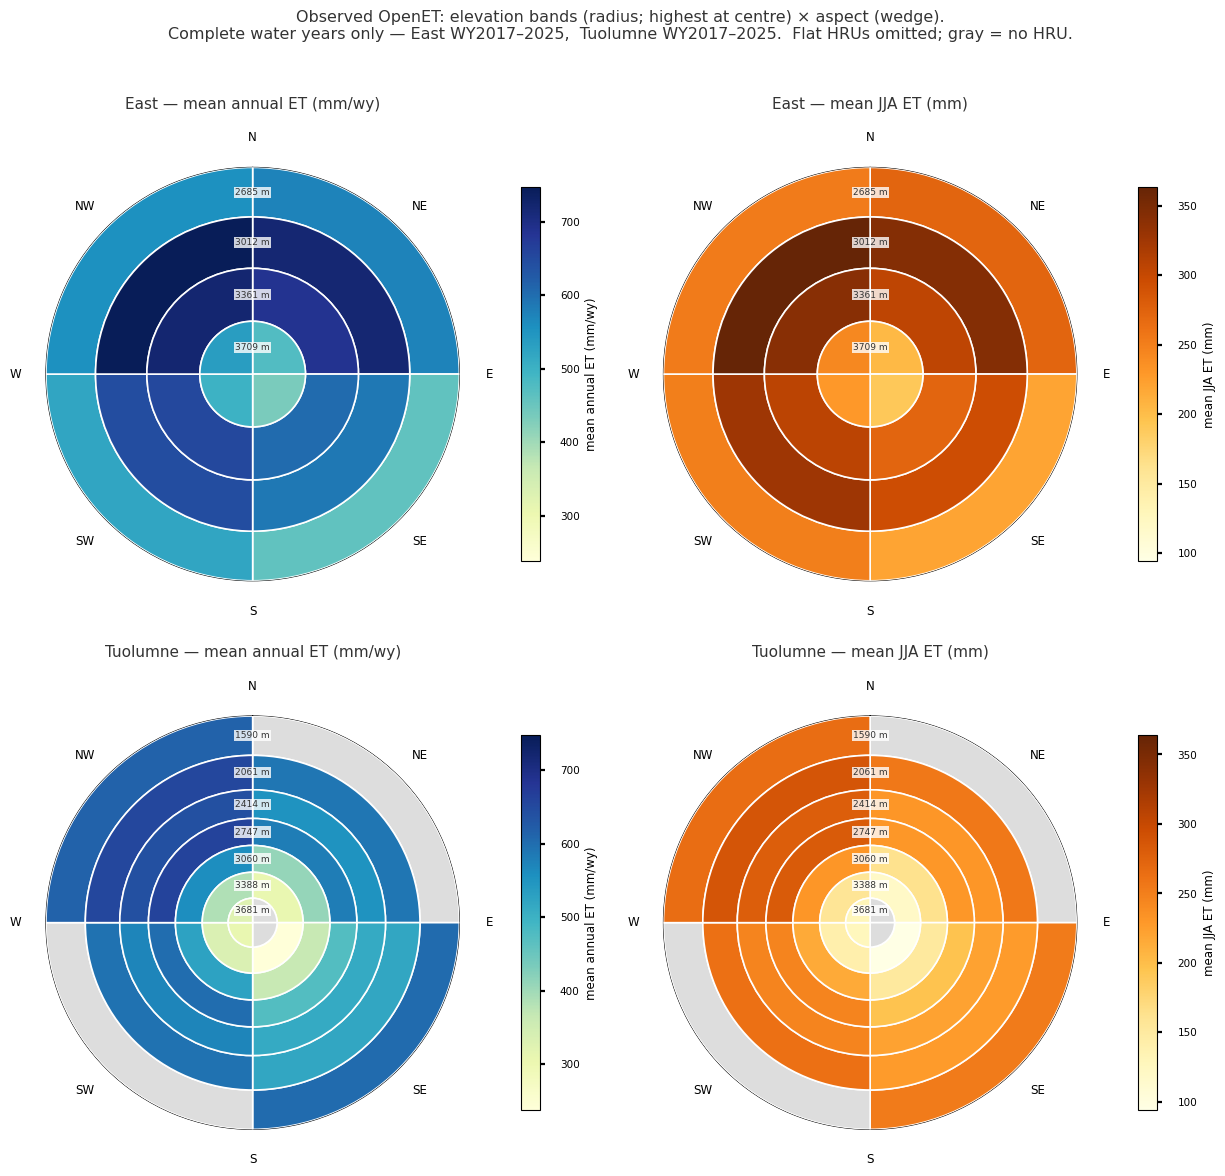

In [44]:
from matplotlib import cm
from matplotlib.colors import Normalize

INK, GRAY = "#333", "#dddddd"
ASP_CENTER = {1: 45, 2: 135, 3: 225, 4: 315}          # NE, SE, SW, NW wedge centres
SEASONS = {"ann": None, "jja": [6, 7, 8]}
LABELS = {"ann": "mean annual ET (mm/wy)", "jja": "mean JJA ET (mm)"}
CMAPS = {"ann": "YlGnBu", "jja": "YlOrBr"}

def water_year(idx):
    return idx.year + (idx.month >= 10)

def seasonal_mean(hru_df, months=None):
    """Mean per-water-year ET total per HRU, using complete water years only."""
    wy = water_year(hru_df.index)
    full = [y for y in np.unique(wy) if (wy == y).sum() == 12]
    d = hru_df[np.isin(wy, full)]
    w = water_year(d.index)
    if months is not None:
        keep = d.index.month.isin(months)
        d, w = d[keep], w[keep]
    return d.groupby(w).sum().mean(axis=0), full

def band_edges(means):
    """Radial band edges from band-mean elevations (midpoints; end bands mirrored)."""
    e = {}
    for i in range(len(means)):
        lo = (means[i-1] + means[i]) / 2 if i > 0 else means[i] - (means[i+1] - means[i]) / 2
        hi = (means[i] + means[i+1]) / 2 if i < len(means)-1 else means[i] + (means[i] - means[i-1]) / 2
        e[i] = (lo, hi)
    return e

# assemble per-HRU values joined to elevation/aspect classes
radial = {}
for name, d in loaded.items():
    g = gpd.read_file(BASINS[name]["domain_dir"] / BASINS[name]["shp"])
    g["id"] = g[HRU_ID].astype(str)
    for var, months in SEASONS.items():
        vals, full = seasonal_mean(d["hru"], months)
        g[var] = g["id"].map(vals.to_dict())
    radial[name] = (g, full)

# shared colour scales across basins so panels are directly comparable
norms = {}
for var in SEASONS:
    allv = np.concatenate([g.loc[g.aspectClas > 0, var].dropna().values for g, _ in radial.values()])
    norms[var] = Normalize(allv.min(), allv.max())

def cell_value(g, band, asp, col):
    sel = g[(g.elevClass == band) & (g.aspectClas == asp)]
    if sel.empty or sel[col].isna().all():
        return np.nan
    return float(np.nansum(sel[col].values * sel["HRU_area"].values) / np.nansum(sel["HRU_area"].values))

nrow = len(radial)
fig = plt.figure(figsize=(12.5, 6 * nrow))
for i, (name, var) in enumerate([(n, v) for n in radial for v in SEASONS]):
    g, full = radial[name]
    bands = sorted(g.loc[g.aspectClas > 0, "elevClass"].unique())
    means = np.array([np.average(g.loc[g.elevClass == b, "elev_mean"],
                                 weights=g.loc[g.elevClass == b, "HRU_area"]) for b in bands])
    edges = band_edges(means)
    e_hi = max(hi for _, hi in edges.values()); e_lo = min(lo for lo, _ in edges.values())

    ax = fig.add_subplot(nrow, 2, i + 1, projection="polar")
    ax.set_theta_zero_location("N"); ax.set_theta_direction(-1)   # N up, clockwise
    for bi, b in enumerate(bands):
        lo, hi = edges[bi]
        for c in (1, 2, 3, 4):                                     # highest band at centre
            v = cell_value(g, b, c, var)
            color = plt.get_cmap(CMAPS[var])(norms[var](v)) if np.isfinite(v) else GRAY
            ax.bar(np.deg2rad(ASP_CENTER[c]), hi - lo, width=np.deg2rad(90), bottom=e_hi - hi,
                   color=color, edgecolor="white", linewidth=1.2, zorder=3, align="center")
    ax.set_rlim(0, e_hi - e_lo); ax.set_yticklabels([]); ax.grid(False)
    ax.set_xticks(np.deg2rad([0, 45, 90, 135, 180, 225, 270, 315]))
    ax.set_xticklabels(["N", "NE", "E", "SE", "S", "SW", "W", "NW"], fontsize=8.5)
    # elevation labels drawn by hand on the N spoke — set_rgrids collapses them at the rim
    for bi, m in enumerate(means):
        lo, hi = edges[bi]
        ax.text(0.0, e_hi - (lo + hi) / 2, f"{int(m)} m", ha="center", va="center",
                fontsize=6.5, color=INK, zorder=6,
                bbox=dict(fc="white", ec="none", alpha=0.8, pad=0.8))
    ax.set_title(f"{name} — {LABELS[var]}", fontsize=11, pad=16, color=INK)
    sm = cm.ScalarMappable(norm=norms[var], cmap=CMAPS[var]); sm.set_array([])
    cb = fig.colorbar(sm, ax=ax, pad=0.11, shrink=0.72)
    cb.set_label(LABELS[var], fontsize=8.5); cb.ax.tick_params(labelsize=7.5)

span = ",  ".join(f"{n} WY{min(f)}–{max(f)}" for n, (_, f) in radial.items())
fig.suptitle("Observed OpenET: elevation bands (radius; highest at centre) × aspect (wedge).\n"
             f"Complete water years only — {span}.  Flat HRUs omitted; gray = no HRU.",
             fontsize=11.5, y=0.99, color=INK)
fig.tight_layout(rect=[0, 0, 1, 1 - 0.05 / nrow])
# FIGDIR = Path("/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/figures/draft")
# fig.savefig(FIGDIR / "openet_radial.png", dpi=130, bbox_inches="tight", facecolor="white")
# plt.show()

## Figure 6 — observed vs modelled ET on the elevation × aspect radial

Three columns, same radial geometry as Figure 5 (**radius = elevation band, highest at
the centre; wedge = aspect**):

1. **OpenET** mean annual ET
2. **SUMMA** mean annual ET (`scalarTotalET + scalarSnowSublimation`, so the model's
   number is total vapour loss and is comparable to what OpenET retrieves)
3. **SUMMA − OpenET** difference

Columns 1 and 2 share one sequential scale so they can be read against each other
directly; column 3 uses a diverging scale centred on zero.

Both products are restricted to the **same complete water years** — the intersection of
the two records — so the difference is not contaminated by a differing period. The
printed summary separates the two things a difference map conflates: the **uniform bias**
(is the model wetter or drier overall?) and the **spatial pattern agreement** (does it put
ET in the same places?), the latter as a spatial correlation and a bias-corrected RMSE.

East: WY2017-2025 (9 yr), 16 sloped HRUs  [OpenET aspect FLIPPED 180 deg]
   area-wt mean ET   OpenET  630.5   SUMMA  427.3   bias -203.2 mm/wy (-32.2%)
   spatial pattern   r = 0.587   bias-corrected RMSE = 78.4 mm/wy
   data ranges       OpenET 434-747   SUMMA 263-490   bias-corr diff -124..+167


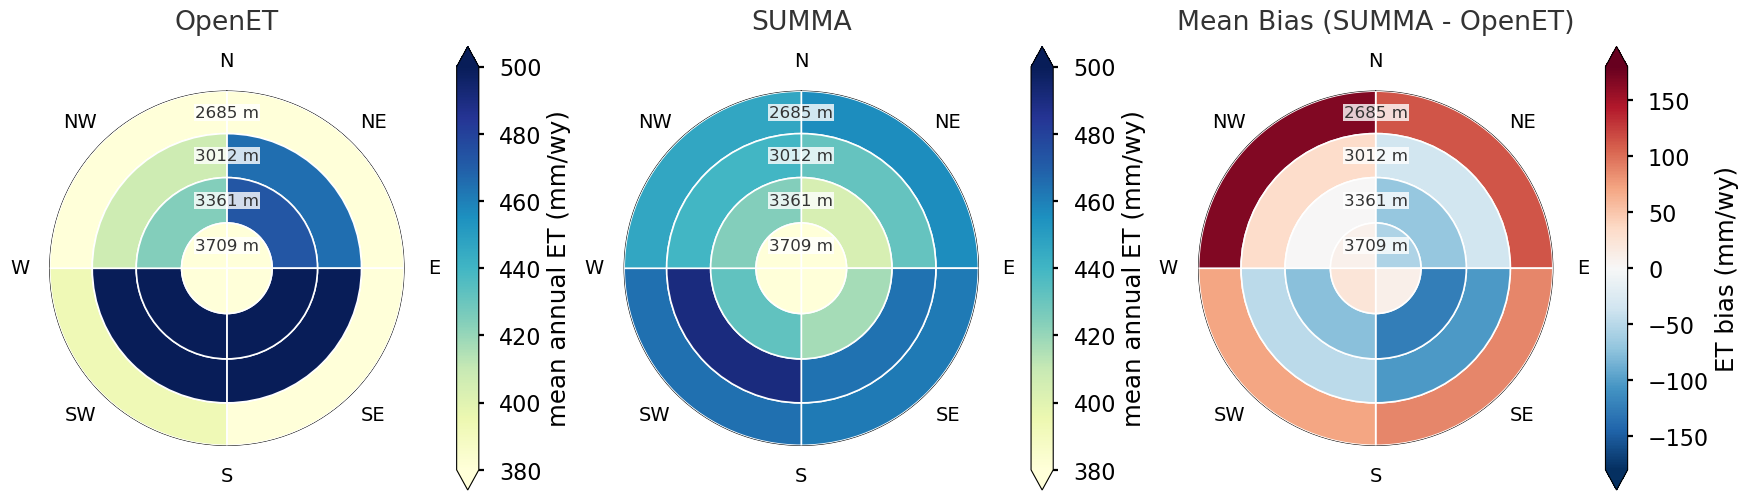

In [112]:
from matplotlib.colors import Normalize

MODEL_ET = {"East": er_ET_results}           # add a basin once its baseline run exists

# ---- colour ranges: set these by hand ----
OBS_VLIM  = (380, 500)       # OpenET panel   (data 434-747)
SIM_VLIM  = (380, 500)      # SUMMA panel    (data 263-490)
DIFF_LIM  = 180             # difference panel spans -DIFF_LIM .. +DIFF_LIM  (data -128..+182)

# Basins whose OpenET aspect should be rotated 180 deg (1<->3, 2<->4) before
# comparing to SUMMA. This is a DATA flip: the OpenET panel rotates AND the
# bias panel / printed stats all use the flipped OpenET. SUMMA is never flipped.
FLIP_OBS_ASPECT = {"East"}
OPP_ASPECT = {1: 3, 2: 4, 3: 1, 4: 2}            # 180-deg aspect-class swap


def aspect_flip_series(g, col):
    """Return per-HRU values of `col` with aspect classes rotated 180 deg.

    For each HRU at (elevation band b, aspect a) the returned value is the
    area-weighted `col` of the OPPOSITE aspect cell (b, OPP_ASPECT[a]).
    Flat HRUs (aspectClas 0) are left unchanged.
    """
    cell = {}
    for (b, a), sub in g.groupby(["elevClass", "aspectClas"]):
        vv, wv = sub[col].values.astype(float), sub["HRU_area"].values.astype(float)
        m = np.isfinite(vv)
        cell[(int(b), int(a))] = (float(np.sum(vv[m] * wv[m]) / np.sum(wv[m]))
                                  if m.any() and np.sum(wv[m]) > 0 else np.nan)
    out = []
    for _, r in g.iterrows():
        b, a = int(r.elevClass), int(r.aspectClas)
        out.append(cell.get((b, OPP_ASPECT.get(a, a)), np.nan))
    return np.array(out, dtype=float)


def wy_totals(hru_df):
    """Per-water-year ET total per HRU (rows = WY, cols = HRU); complete water years only."""
    wy = water_year(hru_df.index)
    full = [y for y in np.unique(wy) if (wy == y).sum() == 12]
    d = hru_df[np.isin(wy, full)]
    return d.groupby(water_year(d.index)).sum(), full


def draw_radial(ax, g, col, cmap, norm):
    """One radial panel: elevation band = radius (highest at centre), aspect = wedge.

    Any aspect flip is baked into the DATA (see aspect_flip_series), so wedge
    positions here are always the true compass aspects.
    """
    bands = sorted(g.loc[g.aspectClas > 0, "elevClass"].unique())
    means = np.array([np.average(g.loc[g.elevClass == b, "elev_mean"],
                                 weights=g.loc[g.elevClass == b, "HRU_area"]) for b in bands])
    edges = band_edges(means)
    e_hi = max(hi for _, hi in edges.values()); e_lo = min(lo for lo, _ in edges.values())
    ax.set_theta_zero_location("N"); ax.set_theta_direction(-1)
    for bi, b in enumerate(bands):
        lo, hi = edges[bi]
        for c in (1, 2, 3, 4):
            v = cell_value(g, b, c, col)
            color = plt.get_cmap(cmap)(norm(v)) if np.isfinite(v) else GRAY
            ax.bar(np.deg2rad(ASP_CENTER[c]), hi - lo, width=np.deg2rad(90), bottom=e_hi - hi,
                   color=color, edgecolor="white", linewidth=1.2, zorder=3, align="center")
    ax.set_rlim(0, e_hi - e_lo); ax.set_yticklabels([]); ax.grid(False)
    ax.set_xticks(np.deg2rad([0, 45, 90, 135, 180, 225, 270, 315]))
    ax.set_xticklabels(["N", "NE", "E", "SE", "S", "SW", "W", "NW"], fontsize=14)
    for bi, m in enumerate(means):
        lo, hi = edges[bi]
        ax.text(0.0, e_hi - (lo + hi) / 2, f"{int(m)} m", ha="center", va="center",
                fontsize=12, color=INK, zorder=6,
                bbox=dict(fc="white", ec="none", alpha=0.8, pad=0.8))


# ---- obs / sim / difference per basin, on a COMMON set of water years ----
cmp_rows = {}
for name, sim_df in MODEL_ET.items():
    if name not in loaded:
        print(f"[skip] {name}: no OpenET loaded"); continue
    obs_tot, obs_full = wy_totals(loaded[name]["hru"])
    sim_tot, sim_full = wy_totals(sim_df)
    common = sorted(set(obs_full) & set(sim_full))
    if not common:
        print(f"[skip] {name}: no overlapping complete water years"); continue

    g = gpd.read_file(BASINS[name]["domain_dir"] / BASINS[name]["shp"])
    g["id"] = g[HRU_ID].astype(str)
    g["sim_ann"] = g[HRU_ID].map(sim_tot.loc[common].mean(axis=0).to_dict())
    g["obs_ann"] = g["id"].map(obs_tot.loc[common].mean(axis=0).to_dict())

    # OpenET used for the comparison: optionally aspect-flipped (SUMMA never is).
    flipped = name in FLIP_OBS_ASPECT
    g["obs_cmp"] = aspect_flip_series(g, "obs_ann") if flipped else g["obs_ann"]
    g["obs_ann_adj"] = g["obs_cmp"] + (g["sim_ann"] - g["obs_cmp"]).mean()                           # OpenET panel shows the comparison field
    g["diff_ann"] = (g["sim_ann"] - g["obs_cmp"]) - (g["sim_ann"] - g["obs_cmp"]).mean()  # bias-corrected
    cmp_rows[name] = (g, common)

    s = g.loc[g.aspectClas > 0].dropna(subset=["obs_cmp", "sim_ann"])
    w = s["HRU_area"] / s["HRU_area"].sum()
    mo, ms = float((s.obs_cmp * w).sum()), float((s.sim_ann * w).sum())
    d = s.sim_ann - s.obs_cmp
    tag = "  [OpenET aspect FLIPPED 180 deg]" if flipped else ""
    print(f"{name}: WY{min(common)}-{max(common)} ({len(common)} yr), {len(s)} sloped HRUs{tag}")
    print(f"   area-wt mean ET   OpenET {mo:6.1f}   SUMMA {ms:6.1f}   bias {ms-mo:+6.1f} mm/wy "
          f"({100*(ms-mo)/mo:+.1f}%)")
    print(f"   spatial pattern   r = {np.corrcoef(s.obs_cmp, s.sim_ann)[0,1]:.3f}   "
          f"bias-corrected RMSE = {np.sqrt(((d - d.mean())**2).mean()):.1f} mm/wy")
    print(f"   data ranges       OpenET {s.obs_cmp.min():.0f}-{s.obs_cmp.max():.0f}   "
          f"SUMMA {s.sim_ann.min():.0f}-{s.sim_ann.max():.0f}   "
          f"bias-corr diff {s.diff_ann.min():+.0f}..{s.diff_ann.max():+.0f}")

PANELS = [("obs_ann_adj",  "OpenET",         "YlGnBu", Normalize(*OBS_VLIM),
           "mean annual ET (mm/wy)"),
          ("sim_ann",  "SUMMA",          "YlGnBu", Normalize(*SIM_VLIM),
           "mean annual ET (mm/wy)"),
          ("diff_ann", "Mean Bias (SUMMA - OpenET)", "RdBu_r", Normalize(-DIFF_LIM, DIFF_LIM),
           "ET bias (mm/wy)")]

plt.style.use("seaborn-v0_8-poster")
nrow = len(cmp_rows)
fig = plt.figure(figsize=(21, 8 * nrow))
for r, (name, (g, common)) in enumerate(cmp_rows.items()):
    for c, (col, ttl, cmap, norm, cblab) in enumerate(PANELS):
        ax = fig.add_subplot(nrow, 3, r * 3 + c + 1, projection="polar")
        draw_radial(ax, g, col, cmap, norm)               # flip is baked into the data
        panel_ttl = ttl
        ax.set_title(panel_ttl, pad=16, color=INK)
        sm = cm.ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
        cb = fig.colorbar(sm, ax=ax, pad=0.11, shrink=0.72, extend="both")
        cb.set_label(cblab,); cb.ax.tick_params()

span = ",  ".join(f"{n} WY{min(y)}-{max(y)}" for n, (_, y) in cmp_rows.items())

# fig.tight_layout(rect=[0, 0, 1, 1 - 0.05 / nrow])
FIGDIR = Path("/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/figures/draft")
fig.savefig(FIGDIR / "et_radial_obs_sim_diff.png", dpi=130, bbox_inches="tight", facecolor="white")
plt.show()


East: normalized spread (max/min across HRUs)  OpenET 1.72x   SUMMA 1.87x
   correlation of normalized ET with elevation   OpenET r = -0.204   SUMMA r = -0.837
   mean |OpenET − SUMMA| after normalizing: 0.141


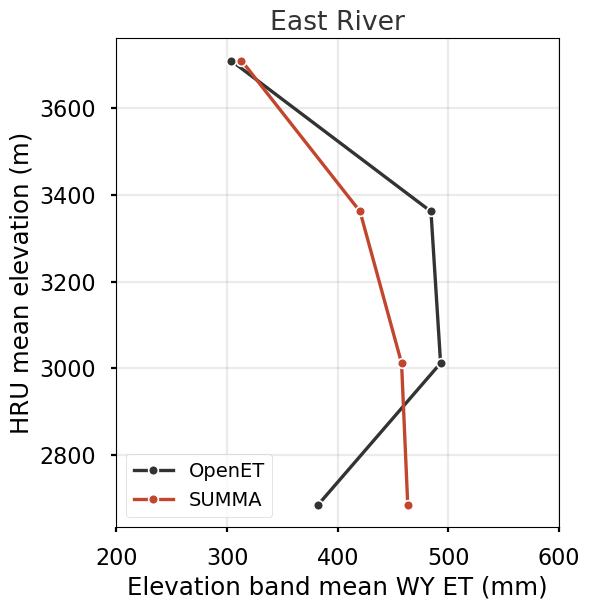

In [87]:
C_OBS, C_SIM = "#333333", "#c2452d"

fig, axes = plt.subplots(1, len(cmp_rows), figsize=(6.0 * len(cmp_rows), 6.2), squeeze=False)
for ax, (name, (g, common)) in zip(axes[0], cmp_rows.items()):
    d = g.dropna(subset=["obs_ann", "sim_ann"]).copy()
    w = d["HRU_area"] / d["HRU_area"].sum()
    # calculate mean bias
    d["bias"] = (d["sim_ann"] - d["obs_ann"]).mean(axis=0)
    for col, c, lab in (("obs_ann", C_OBS, "OpenET"), ("sim_ann", C_SIM, "SUMMA")):
        if col == "obs_ann":
            norm = d[col] + d["bias"]
        else:
            norm = d[col]
        # divide by its OWN basin mean
        # ax.scatter(norm, d["elev_mean"], s=34, color=c, alpha=0.45, lw=0, zorder=2)
        band = (d.assign(n=norm)
                  .groupby("elevClass")
                  .apply(lambda x: pd.Series(
                      {"n": np.average(x["n"], weights=x["HRU_area"]),
                       "z": np.average(x["elev_mean"], weights=x["HRU_area"])}))
                  .sort_values("z"))
        ax.plot(band["n"], band["z"], color=c, lw=2.4, marker="o", ms=7,
                mec="white", mew=1.2, zorder=4, label=lab)
    ax.set_xlabel("Elevation band mean WY ET (mm)"); 
    ax.set_ylabel("HRU mean elevation (m)")
    ax.set_title(f"{name} River",
                  color=INK)
    ax.legend(fontsize=14, loc="lower left"); 
    ax.grid(alpha=0.25)

    # how different are the two shapes, once magnitude is removed?
    no = d["obs_ann"] / float((d["obs_ann"] * w).sum())
    ns = d["sim_ann"] / float((d["sim_ann"] * w).sum())
    print(f"{name}: normalized spread (max/min across HRUs)  "
          f"OpenET {no.max()/no.min():.2f}x   SUMMA {ns.max()/ns.min():.2f}x")
    print(f"   correlation of normalized ET with elevation   "
          f"OpenET r = {np.corrcoef(no, d.elev_mean)[0,1]:+.3f}   "
          f"SUMMA r = {np.corrcoef(ns, d.elev_mean)[0,1]:+.3f}")
    print(f"   mean |OpenET − SUMMA| after normalizing: {np.abs(no - ns).mean():.3f}")
ax.set_xlim(200,600)

fig.tight_layout()
FIGDIR = Path("/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/figures/draft")
fig.savefig(FIGDIR / "et_hypsometry.png", dpi=130, bbox_inches="tight", facecolor="white")
plt.show()

Tuolumne: WY2017-2025 (9 yr), 22 sloped HRUs  [OpenET aspect FLIPPED 180 deg]
   area-wt mean ET   OpenET  497.4   SUMMA  456.1   bias  -41.2 mm/wy (-8.3%)
   spatial pattern   r = 0.566   bias-corrected RMSE = 110.1 mm/wy
   data ranges       OpenET 238-660   SUMMA 349-729   bias-corr diff -166..+225


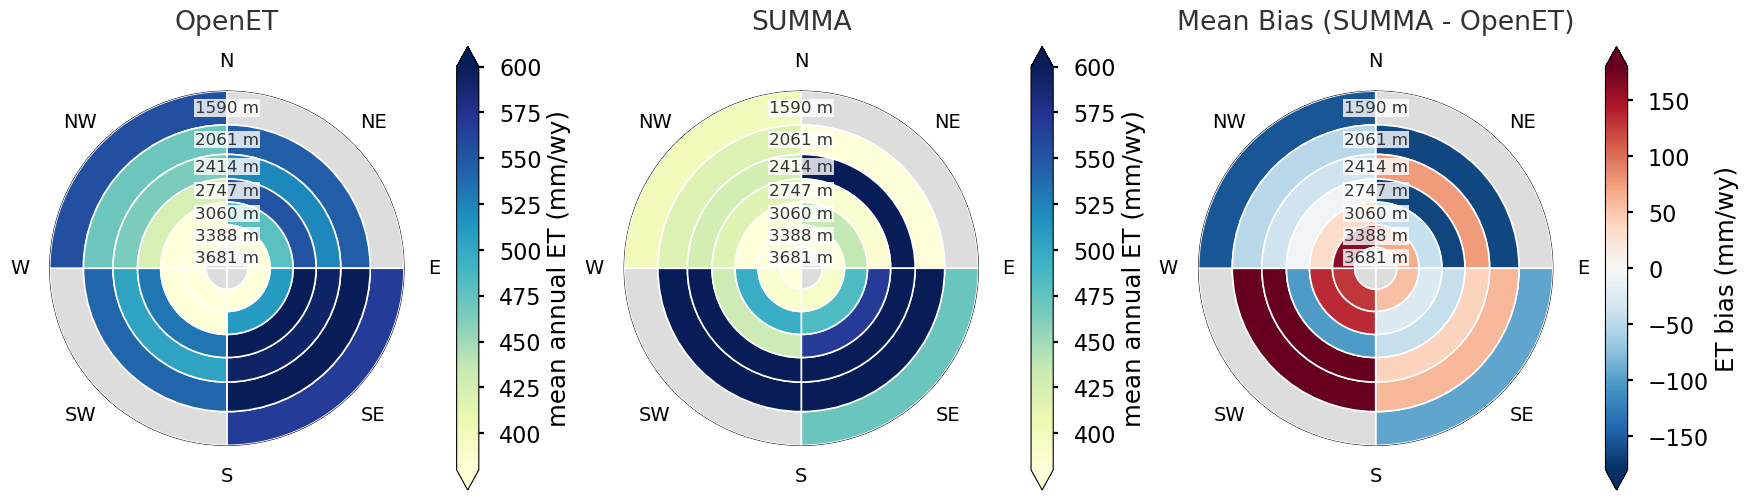

In [108]:
from matplotlib.colors import Normalize

MODEL_ET = {"Tuolumne": TR_ET_results}           # add a basin once its baseline run exists

# ---- colour ranges: set these by hand ----
OBS_VLIM  = (380, 600)       # OpenET panel   (data 434-747)
SIM_VLIM  = (380, 600)      # SUMMA panel    (data 263-490)
DIFF_LIM  = 180             # difference panel spans -DIFF_LIM .. +DIFF_LIM  (data -128..+182)

# Basins whose OpenET aspect should be rotated 180 deg (1<->3, 2<->4) before
# comparing to SUMMA. This is a DATA flip: the OpenET panel rotates AND the
# bias panel / printed stats all use the flipped OpenET. SUMMA is never flipped.
FLIP_OBS_ASPECT = {"Tuolumne"}
OPP_ASPECT = {1: 3, 2: 4, 3: 1, 4: 2}            # 180-deg aspect-class swap


def aspect_flip_series(g, col):
    """Return per-HRU values of `col` with aspect classes rotated 180 deg.

    For each HRU at (elevation band b, aspect a) the returned value is the
    area-weighted `col` of the OPPOSITE aspect cell (b, OPP_ASPECT[a]).
    Flat HRUs (aspectClas 0) are left unchanged.
    """
    cell = {}
    for (b, a), sub in g.groupby(["elevClass", "aspectClas"]):
        vv, wv = sub[col].values.astype(float), sub["HRU_area"].values.astype(float)
        m = np.isfinite(vv)
        cell[(int(b), int(a))] = (float(np.sum(vv[m] * wv[m]) / np.sum(wv[m]))
                                  if m.any() and np.sum(wv[m]) > 0 else np.nan)
    out = []
    for _, r in g.iterrows():
        b, a = int(r.elevClass), int(r.aspectClas)
        out.append(cell.get((b, OPP_ASPECT.get(a, a)), np.nan))
    return np.array(out, dtype=float)


def wy_totals(hru_df):
    """Per-water-year ET total per HRU (rows = WY, cols = HRU); complete water years only."""
    wy = water_year(hru_df.index)
    full = [y for y in np.unique(wy) if (wy == y).sum() == 12]
    d = hru_df[np.isin(wy, full)]
    return d.groupby(water_year(d.index)).sum(), full


def draw_radial(ax, g, col, cmap, norm):
    """One radial panel: elevation band = radius (highest at centre), aspect = wedge.

    Any aspect flip is baked into the DATA (see aspect_flip_series), so wedge
    positions here are always the true compass aspects.
    """
    bands = sorted(g.loc[g.aspectClas > 0, "elevClass"].unique())
    means = np.array([np.average(g.loc[g.elevClass == b, "elev_mean"],
                                 weights=g.loc[g.elevClass == b, "HRU_area"]) for b in bands])
    edges = band_edges(means)
    e_hi = max(hi for _, hi in edges.values()); e_lo = min(lo for lo, _ in edges.values())
    ax.set_theta_zero_location("N"); ax.set_theta_direction(-1)
    for bi, b in enumerate(bands):
        lo, hi = edges[bi]
        for c in (1, 2, 3, 4):
            v = cell_value(g, b, c, col)
            color = plt.get_cmap(cmap)(norm(v)) if np.isfinite(v) else GRAY
            ax.bar(np.deg2rad(ASP_CENTER[c]), hi - lo, width=np.deg2rad(90), bottom=e_hi - hi,
                   color=color, edgecolor="white", linewidth=1.2, zorder=3, align="center")
    ax.set_rlim(0, e_hi - e_lo); ax.set_yticklabels([]); ax.grid(False)
    ax.set_xticks(np.deg2rad([0, 45, 90, 135, 180, 225, 270, 315]))
    ax.set_xticklabels(["N", "NE", "E", "SE", "S", "SW", "W", "NW"], fontsize=14)
    for bi, m in enumerate(means):
        lo, hi = edges[bi]
        ax.text(0.0, e_hi - (lo + hi) / 2, f"{int(m)} m", ha="center", va="center",
                fontsize=12, color=INK, zorder=6,
                bbox=dict(fc="white", ec="none", alpha=0.8, pad=0.8))


# ---- obs / sim / difference per basin, on a COMMON set of water years ----
cmp_rows = {}
for name, sim_df in MODEL_ET.items():
    if name not in loaded:
        print(f"[skip] {name}: no OpenET loaded"); continue
    obs_tot, obs_full = wy_totals(loaded[name]["hru"])
    sim_tot, sim_full = wy_totals(sim_df)
    common = sorted(set(obs_full) & set(sim_full))
    if not common:
        print(f"[skip] {name}: no overlapping complete water years"); continue

    g = gpd.read_file(BASINS[name]["domain_dir"] / BASINS[name]["shp"])
    g["id"] = g[HRU_ID].astype(str)
    g["sim_ann"] = g[HRU_ID].map(sim_tot.loc[common].mean(axis=0).to_dict())
    g["obs_ann"] = g["id"].map(obs_tot.loc[common].mean(axis=0).to_dict())

    # OpenET used for the comparison: optionally aspect-flipped (SUMMA never is).
    flipped = name in FLIP_OBS_ASPECT
    g["obs_cmp"] = aspect_flip_series(g, "obs_ann") if flipped else g["obs_ann"]
    g["obs_ann_adj"] = g["obs_cmp"] + (g["sim_ann"] - g["obs_cmp"]).mean()                           # OpenET panel shows the comparison field
    g["diff_ann"] = (g["sim_ann"] - g["obs_cmp"]) - (g["sim_ann"] - g["obs_cmp"]).mean()  # bias-corrected
    cmp_rows[name] = (g, common)

    s = g.loc[g.aspectClas > 0].dropna(subset=["obs_cmp", "sim_ann"])
    w = s["HRU_area"] / s["HRU_area"].sum()
    mo, ms = float((s.obs_cmp * w).sum()), float((s.sim_ann * w).sum())
    d = s.sim_ann - s.obs_cmp
    tag = "  [OpenET aspect FLIPPED 180 deg]" if flipped else ""
    print(f"{name}: WY{min(common)}-{max(common)} ({len(common)} yr), {len(s)} sloped HRUs{tag}")
    print(f"   area-wt mean ET   OpenET {mo:6.1f}   SUMMA {ms:6.1f}   bias {ms-mo:+6.1f} mm/wy "
          f"({100*(ms-mo)/mo:+.1f}%)")
    print(f"   spatial pattern   r = {np.corrcoef(s.obs_cmp, s.sim_ann)[0,1]:.3f}   "
          f"bias-corrected RMSE = {np.sqrt(((d - d.mean())**2).mean()):.1f} mm/wy")
    print(f"   data ranges       OpenET {s.obs_cmp.min():.0f}-{s.obs_cmp.max():.0f}   "
          f"SUMMA {s.sim_ann.min():.0f}-{s.sim_ann.max():.0f}   "
          f"bias-corr diff {s.diff_ann.min():+.0f}..{s.diff_ann.max():+.0f}")

PANELS = [("obs_ann_adj",  "OpenET",         "YlGnBu", Normalize(*OBS_VLIM),
           "mean annual ET (mm/wy)"),
          ("sim_ann",  "SUMMA",          "YlGnBu", Normalize(*SIM_VLIM),
           "mean annual ET (mm/wy)"),
          ("diff_ann", "Mean Bias (SUMMA - OpenET)", "RdBu_r", Normalize(-DIFF_LIM, DIFF_LIM),
           "ET bias (mm/wy)")]

plt.style.use("seaborn-v0_8-poster")
nrow = len(cmp_rows)
fig = plt.figure(figsize=(21, 8 * nrow))
for r, (name, (g, common)) in enumerate(cmp_rows.items()):
    for c, (col, ttl, cmap, norm, cblab) in enumerate(PANELS):
        ax = fig.add_subplot(nrow, 3, r * 3 + c + 1, projection="polar")
        draw_radial(ax, g, col, cmap, norm)               # flip is baked into the data
        panel_ttl = ttl
        ax.set_title(panel_ttl, pad=16, color=INK)
        sm = cm.ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
        cb = fig.colorbar(sm, ax=ax, pad=0.11, shrink=0.72, extend="both")
        cb.set_label(cblab,); cb.ax.tick_params()

span = ",  ".join(f"{n} WY{min(y)}-{max(y)}" for n, (_, y) in cmp_rows.items())

# fig.tight_layout(rect=[0, 0, 1, 1 - 0.05 / nrow])
FIGDIR = Path("/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/figures/draft")
fig.savefig(FIGDIR / "et_radial_obs_sim_diff.png", dpi=130, bbox_inches="tight", facecolor="white")
plt.show()


Tuolumne: normalized spread (max/min across HRUs)  OpenET 3.02x   SUMMA 3.14x
   correlation of normalized ET with elevation   OpenET r = -0.759   SUMMA r = -0.525
   mean |OpenET − SUMMA| after normalizing: 0.270


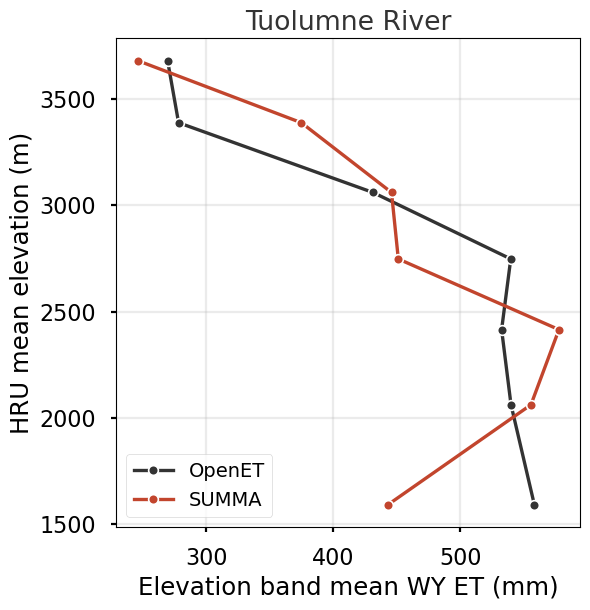

In [89]:
C_OBS, C_SIM = "#333333", "#c2452d"

fig, axes = plt.subplots(1, len(cmp_rows), figsize=(6.0 * len(cmp_rows), 6.2), squeeze=False)
for ax, (name, (g, common)) in zip(axes[0], cmp_rows.items()):
    d = g.dropna(subset=["obs_ann", "sim_ann"]).copy()
    w = d["HRU_area"] / d["HRU_area"].sum()
    # calculate mean bias
    d["bias"] = (d["sim_ann"] - d["obs_ann"]).mean(axis=0)
    for col, c, lab in (("obs_ann", C_OBS, "OpenET"), ("sim_ann", C_SIM, "SUMMA")):
        if col == "obs_ann":
            norm = d[col] + d["bias"]
        else:
            norm = d[col]
        # divide by its OWN basin mean
        # ax.scatter(norm, d["elev_mean"], s=34, color=c, alpha=0.45, lw=0, zorder=2)
        band = (d.assign(n=norm)
                  .groupby("elevClass")
                  .apply(lambda x: pd.Series(
                      {"n": np.average(x["n"], weights=x["HRU_area"]),
                       "z": np.average(x["elev_mean"], weights=x["HRU_area"])}))
                  .sort_values("z"))
        ax.plot(band["n"], band["z"], color=c, lw=2.4, marker="o", ms=7,
                mec="white", mew=1.2, zorder=4, label=lab)
    ax.set_xlabel("Elevation band mean WY ET (mm)"); 
    ax.set_ylabel("HRU mean elevation (m)")
    ax.set_title(f"{name} River",
                  color=INK)
    ax.legend(fontsize=14, loc="lower left"); 
    ax.grid(alpha=0.25)

    # how different are the two shapes, once magnitude is removed?
    no = d["obs_ann"] / float((d["obs_ann"] * w).sum())
    ns = d["sim_ann"] / float((d["sim_ann"] * w).sum())
    print(f"{name}: normalized spread (max/min across HRUs)  "
          f"OpenET {no.max()/no.min():.2f}x   SUMMA {ns.max()/ns.min():.2f}x")
    print(f"   correlation of normalized ET with elevation   "
          f"OpenET r = {np.corrcoef(no, d.elev_mean)[0,1]:+.3f}   "
          f"SUMMA r = {np.corrcoef(ns, d.elev_mean)[0,1]:+.3f}")
    print(f"   mean |OpenET − SUMMA| after normalizing: {np.abs(no - ns).mean():.3f}")

fig.tight_layout()
FIGDIR = Path("/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/figures/draft")
fig.savefig(FIGDIR / "et_hypsometry.png", dpi=130, bbox_inches="tight", facecolor="white")
plt.show()

## Figure 7 — land cover on the elevation × aspect radial

Where the trees are. Same geometry as Figures 5–6, filled by the **dominant MODIS land
cover class** in each band × aspect cell, computed as pixel fractions from the 30 m
NLCD→MODIS raster (the same source as `vegTypeIndex` in `attributes.nc`).

- **Fill** = dominant class.
- **Hatch** = the cell has a substantial **deciduous + mixed forest** fraction
  (≥ `HATCH_MIN`), i.e. it is not purely evergreen.
- **Number in each wedge** = total forest fraction (classes 1–5), so "trees vs no trees"
  is readable directly rather than inferred from the class name.

East: area-wt forest fraction 48.0%  (range 0–87%)
[skip] Tuolumne: no land class raster


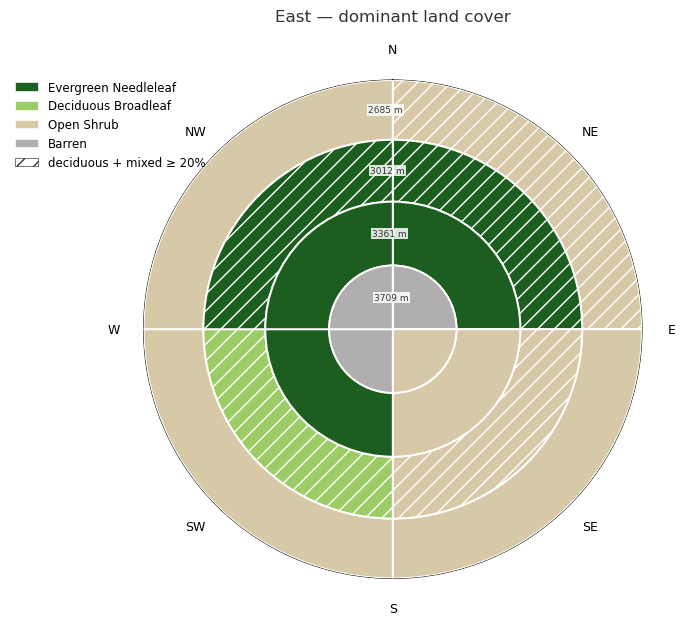

In [80]:
import rasterio
from rasterio.mask import mask as rio_mask
from matplotlib.patches import Patch

# 30 m NLCD reclassified to MODIS classes — the source of vegTypeIndex in attributes.nc
LC_TIF = {"East": "attributes/landclass/"
                  "domain_East_River_distributed_elevAspect_NLCD_land_classes_modis.tif",
          "Tuolumne": "attributes/landclass/"
                      "domain_Tuolumne_River_distributed_elevAspect_NLCD_land_classes_modis.tif"}

HATCH_MIN = 0.20            # hatch a cell when deciduous + mixed forest >= this fraction

LC_NAME = {1: "Evergreen Needleleaf", 2: "Evergreen Broadleaf", 3: "Deciduous Needleleaf",
           4: "Deciduous Broadleaf", 5: "Mixed Forest", 6: "Closed Shrub", 7: "Open Shrub",
           8: "Woody Savanna", 9: "Savanna", 10: "Grassland", 11: "Wetland", 12: "Cropland",
           13: "Urban", 14: "Crop Mosaic", 15: "Snow / Ice", 16: "Barren", 17: "Water"}
# conventional land-cover colours: greens for trees, tan for shrub, gray for barren
LC_COLOR = {1: "#1b5e20", 2: "#2e7d32", 3: "#7cb342", 4: "#9ccc65", 5: "#558b2f",
            6: "#bcaaa4", 7: "#d7c9a7", 8: "#a5b06a", 9: "#c5cf8a", 10: "#eae3b0",
            11: "#4fa3a5", 12: "#e6b422", 13: "#9e9e9e", 14: "#dcc98a", 15: "#eceff1",
            16: "#b0aeae", 17: "#4a90d9"}
FOREST = {1, 2, 3, 4, 5}

# ---- per-HRU land cover fractions ----
lc_rows = {}
for name, cfg in BASINS.items():
    tif = cfg["domain_dir"] / LC_TIF.get(name, "")
    shp = cfg["domain_dir"] / cfg["shp"]
    if not tif.exists() or not shp.exists():
        print(f"[skip] {name}: no land class raster"); continue
    g = gpd.read_file(shp)
    with rasterio.open(tif) as r:
        gg = g.to_crs(r.crs)
        dom, forest, dm = [], [], []
        for _, row in gg.iterrows():
            out, _ = rio_mask(r, [row.geometry], crop=True, filled=True, nodata=0)
            a = out[0][out[0] > 0]
            if a.size == 0:
                dom.append(np.nan); forest.append(np.nan); dm.append(np.nan); continue
            v, c = np.unique(a, return_counts=True); f = c / c.sum()
            dom.append(int(v[np.argmax(f)]))
            forest.append(float(f[np.isin(v, list(FOREST))].sum()))
            dm.append(float(f[np.isin(v, [4, 5])].sum()))
    g["lc_dom"], g["forest_frac"], g["dm_frac"] = dom, forest, dm
    lc_rows[name] = g
    s = g.loc[g.aspectClas > 0]
    w = s["HRU_area"] / s["HRU_area"].sum()
    print(f"{name}: area-wt forest fraction {100*float((s.forest_frac*w).sum()):.1f}%  "
          f"(range {100*s.forest_frac.min():.0f}–{100*s.forest_frac.max():.0f}%)")

# ---- plot ----
fig = plt.figure(figsize=(6.8 * len(lc_rows), 6.6))
for i, (name, g) in enumerate(lc_rows.items()):
    bands = sorted(g.loc[g.aspectClas > 0, "elevClass"].unique())
    means = np.array([np.average(g.loc[g.elevClass == b, "elev_mean"],
                                 weights=g.loc[g.elevClass == b, "HRU_area"]) for b in bands])
    edges = band_edges(means)
    e_hi = max(hi for _, hi in edges.values()); e_lo = min(lo for lo, _ in edges.values())

    ax = fig.add_subplot(1, len(lc_rows), i + 1, projection="polar")
    ax.set_theta_zero_location("N"); ax.set_theta_direction(-1)
    for bi, b in enumerate(bands):
        lo, hi = edges[bi]
        for c in (1, 2, 3, 4):
            sel = g[(g.elevClass == b) & (g.aspectClas == c)]
            if sel.empty or sel["lc_dom"].isna().all():
                color, hatch, lab = GRAY, None, None
            else:
                row = sel.loc[sel["HRU_area"].idxmax()]      # largest HRU in the cell
                color = LC_COLOR.get(int(row.lc_dom), GRAY)
                hatch = "//" if row.dm_frac >= HATCH_MIN else None
                lab = None#f"{100*row.forest_frac:.0f}%"
            ax.bar(np.deg2rad(ASP_CENTER[c]), hi - lo, width=np.deg2rad(90), bottom=e_hi - hi,
                   color=color, edgecolor="white", linewidth=1.4, zorder=3,
                   hatch=hatch, align="center")
            if lab:
                ax.text(np.deg2rad(ASP_CENTER[c]), e_hi - (lo + hi) / 2, lab,
                        ha="center", va="center", fontsize=8, color=INK, zorder=7,
                        bbox=dict(fc="white", ec="none", alpha=0.72, pad=1.0))
    ax.set_rlim(0, e_hi - e_lo); ax.set_yticklabels([]); ax.grid(False)
    ax.set_xticks(np.deg2rad([0, 45, 90, 135, 180, 225, 270, 315]))
    ax.set_xticklabels(["N", "NE", "E", "SE", "S", "SW", "W", "NW"], fontsize=9)
    for bi, m in enumerate(means):
        lo, hi = edges[bi]
        ax.text(np.deg2rad(-2), e_hi - (lo + hi) / 2, f"{int(m)} m", ha="center", va="center",
                fontsize=6.5, color=INK, zorder=8,
                bbox=dict(fc="white", ec="none", alpha=0.85, pad=0.8))
    ax.set_title(f"{name} — dominant land cover", fontsize=12, pad=16, color=INK)

    present = sorted({int(v) for v in g.loc[g.aspectClas > 0, "lc_dom"].dropna().unique()})
    handles = [Patch(fc=LC_COLOR.get(k, GRAY), ec="white", label=LC_NAME.get(k, k))
               for k in present]
    handles.append(Patch(fc="white", ec=INK, hatch="//",
                         label=f"deciduous + mixed ≥ {HATCH_MIN:.0%}"))
    ax.legend(handles=handles, loc="upper left", bbox_to_anchor=(-0.28, 1.02),
              fontsize=8.5, frameon=False)
fig.tight_layout()
FIGDIR = Path("/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/figures/draft")
fig.savefig(FIGDIR / "landcover_radial.png", dpi=130, bbox_inches="tight", facecolor="white")
plt.show()

## Figure 8 — ET hypsometry, normalized

How ET varies with elevation, with each product divided by its own area-weighted basin
mean. Normalizing removes the −32% magnitude bias entirely and leaves only the **shape**:
whether OpenET and SUMMA distribute ET the same way with elevation, independent of how
much total water each thinks there is.

A value of 1.0 is that product's own basin mean, so the two curves are directly
comparable. Points are individual HRUs; the heavy line is the area-weighted band mean.

## ET observations during SOS/SPLASH

In [113]:
sos_ds = xr.open_dataset("/home/dlhogan/projects/phd-repos/Synoptic-Sublimation/01_data/processed_data/sos/sos_ds_1H_storage.nc")

TURBULENT_FLUX_VARIABLES = [
                            'Hl_webb_10m_uw',
                            'Hl_webb_10m_ue',
                            'Hl_webb_10m_d', 
                            'Hl_webb_10m_c',
                            ]

<Axes: xlabel='time'>

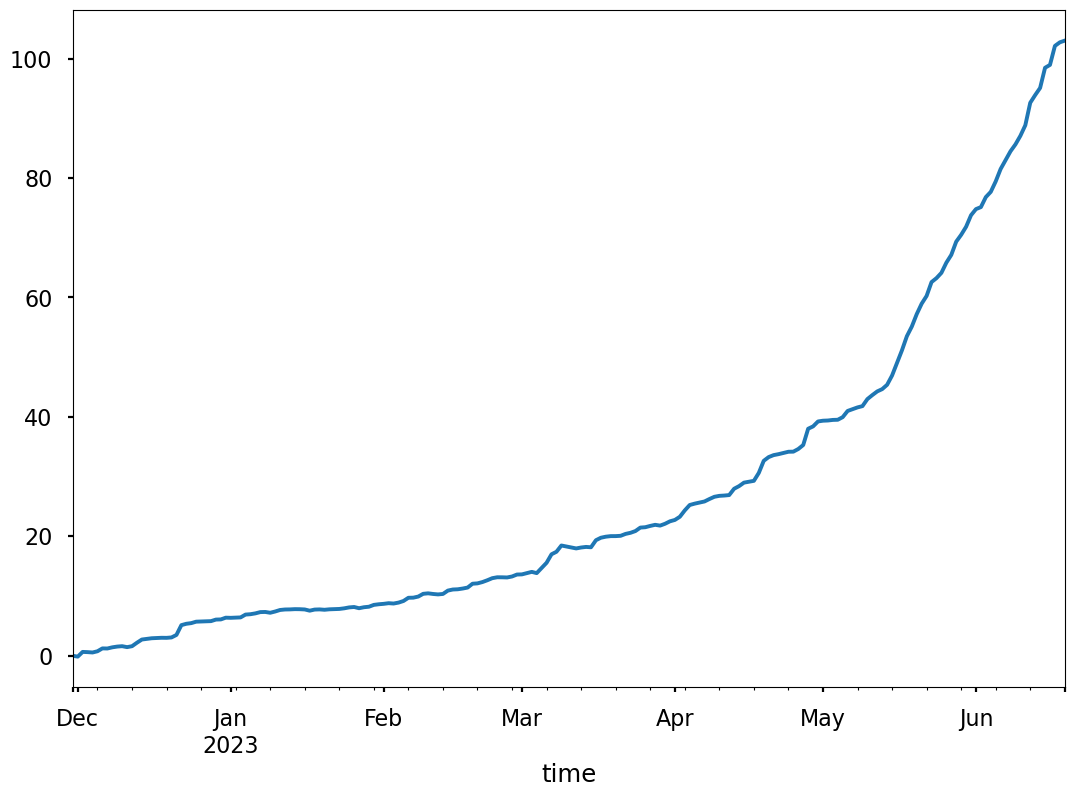

In [114]:
latent_heat_vaporization = 2.501e6  # J/kg
latent_heat_sublimation = 2.834e6  # J/kg

# convert from W/m2 to mm/day
def convert_to_mm_day(w_m2, latent_heat, freeze_mask=None):
    return (w_m2 * 86400) / latent_heat

sos_ds_daily = sos_ds[TURBULENT_FLUX_VARIABLES + ['T_10m_c']].resample(time="1D").mean().to_pandas()
freeze_mask = sos_ds_daily['T_10m_c'] > 0

# compute ET in mm/day for above freezing days
sos_ds_daily['ET_mm_day'] = convert_to_mm_day(sos_ds_daily['Hl_webb_10m_c'].where(freeze_mask), latent_heat_vaporization)
# fill in ET for below freezing days using sublimation
sos_ds_daily['ET_mm_day'] = sos_ds_daily['ET_mm_day'].fillna(convert_to_mm_day(sos_ds_daily['Hl_webb_10m_c'].where(~freeze_mask), latent_heat_sublimation))
sos_ds_daily['ET_mm_day'].cumsum().plot()

Text(0.5, 0, '')

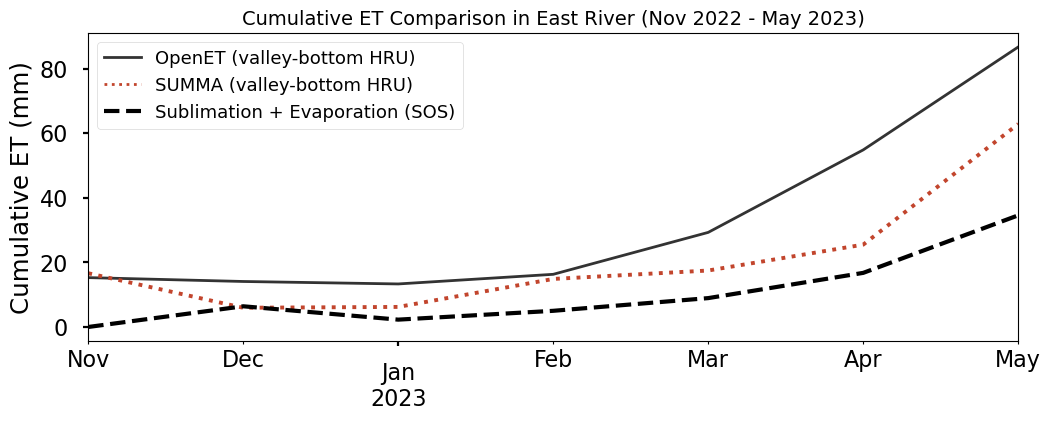

In [134]:
fig, ax = plt.subplots(figsize=(12, 4))
loaded['East']['hru'].loc['2022-11-01':'2023-05-01'].resample('1ME').sum()['14'].plot(ax=ax, label=None, color=C_OBS, lw=2)
er_ET_results[14].loc['2022-11-01':'2023-05-31'].resample('1MS').sum().plot(ax=ax, color=C_SIM, ls=':')
sos_ds_daily['ET_mm_day'].loc['2022-11-01':'2023-05-31'].resample('1MS').sum().plot(ax=ax, color='black', ls='--', lw=3)
# manual legend 
handles = [plt.Line2D([0], [0], color=C_OBS, lw=2, label='OpenET (valley-bottom HRU)'),
           plt.Line2D([0], [0], color=C_SIM, lw=2, ls=':', label='SUMMA (valley-bottom HRU)'),
           plt.Line2D([0], [0], color='black', lw=3, ls='--', label='Sublimation + Evaporation (SOS)'),
           ]
ax.set_ylabel('Cumulative ET (mm)')
ax.set_title('Cumulative ET Comparison in East River (Nov 2022 - May 2023)', fontsize=14)
ax.legend(handles=handles, loc='upper left', fontsize=13)
ax.set_xlabel("")

## Notes

- **gridded + easymore** vs **polygon-reduce** agree closely in the high-ET season
  (validated on East 2020: <1 mm May–Dec, ~4.5% mean-abs over the year). Larger
  *percentage* gaps appear only in low-ET winter months where absolute ET is a few mm.
- The gridded product is the reusable one: remap the same basin grid to elevTPI /
  elevation discretizations with `remap_et_to_hrus.py` (weights are cached).
- Per-HRU CSVs feed `prepare_observations.py` for ET-based calibration targets.
